# Seasonal Agriculture Performance Analysis
### VOIS AICTE Internship — Major Project

This notebook analyzes how agricultural performance (yield, cost, revenue,
profit, resource usage) varies across three seasons — **Kharif, Rabi, Zaid**
— using the seasonal agriculture performance dataset.


**Project Goal**

The goal of this project is to analyze seasonal agricultural performance data and uncover meaningful patterns, trends, and relationships that explain how farming outcomes — yield, resource usage, and profitability — change across the Kharif, Rabi, and Zaid seasons, in order to support evidence-based agricultural planning.

**Problem Statement**

Agricultural performance is shaped by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. However, raw agricultural data does not clearly reveal how performance actually changes from one season to another. This project addresses that gap by analyzing a seasonal agriculture dataset to identify meaningful patterns, trends, relationships, and variations in agricultural performance across seasons.

**Project Objectives**

* Explore and understand the structure and content of the dataset
* Clean and prepare the data for reliable analysis
* Examine how agricultural performance varies across seasons
* Identify important seasonal patterns and trends
* Investigate relationships between seasonal environmental conditions and agricultural outcomes
* Compare relevant groups (crops, states, irrigation methods) within each season
* Identify statistically significant differences and unusual patterns in the data
* Apply appropriate statistical and visualization techniques
* Interpret findings based strictly on evidence from the dataset
* Develop meaningful, data-driven conclusions and recommendations

In [154]:
# ---------------------------------------------------------------
# STEP 0: Import libraries
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

# 'display()' is a Jupyter/Colab-only function. This fallback lets the script
# also run as a plain .py file outside a notebook without crashing.
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

In [122]:
# ---------------------------------------------------------------
# STEP 1: Load the dataset
# ---------------------------------------------------------------
# If running in Colab and the file isn't already in the working directory,
# uncomment the block below to upload it manually.
#
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [123]:
# ---------------------------------------------------------------
# STEP 2: Explore and understand the dataset
# ---------------------------------------------------------------
print("Column info:")
df.info()

print("\nStatistical summary (numeric columns):")
display(df.describe())

print("\nSeasons present:", df["Season"].unique())
print("Crops present:", df["Crop"].unique())
print("States present:", df["State"].unique())
print("Irrigation methods:", df["Irrigation_Method"].unique())

print("\nRecords per season:")
print(df["Season"].value_counts())

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000



Seasons present: ['Kharif' 'Rabi' 'Zaid']
Crops present: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
States present: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Irrigation methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']

Records per season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [124]:
# ---------------------------------------------------------------
# STEP 3: Data cleaning and preparation
# ---------------------------------------------------------------

# 3a. Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 3b. Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# 3c. Handle missing values.
# Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha have some missing values.
# Since these vary meaningfully by season, we fill each missing value with
# the median for that column WITHIN its own season (more accurate than a
# single global median).
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))

print("\nMissing values after cleaning:", df.isnull().sum().sum())

# 3d. Check for negative / impossible values in key numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
for col in ["Farm_Area_Hectares", "Yield_Tonnes_Ha", "Production_Tonnes",
            "Rainfall_mm", "Fertilizer_kg_ha"]:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"Warning: {col} has {n_neg} negative values")

# 3e. Outlier check using IQR method (report only, not removed — outliers in
# profit/cost can be genuine extreme farms, not necessarily errors)
def count_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

print("\nOutlier counts (IQR method) in key columns:")
for col in ["Yield_Tonnes_Ha", "Profit_INR", "Total_Cost_INR", "Rainfall_mm"]:
    print(f"  {col}: {count_outliers(df[col])} outliers")

# 3f. Feature engineering — useful derived columns for analysis
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"].replace(0, np.nan)) * 100
df["Cost_per_Hectare"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Revenue_per_Hectare"] = df["Revenue_INR"] / df["Farm_Area_Hectares"]

print("\nCleaned dataset ready. Shape:", df.shape)
df.head()

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0

Missing values after cleaning: 0

Outlier counts (IQR method) in key columns:
  Yield_Tonnes_Ha: 302 outliers
  Profit_INR: 404 outliers
  Total_Cost_INR: 0 outliers
  Rainfall_mm: 0 outliers

Cleaned dataset ready. Shape: (4000, 31)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,80494.339623,58132.075472
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,75398.315467,6186.983155
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,64858.024691,39190.534979
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,65876.444444,44608.888889
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,80275.296912,45987.410926


In [125]:
# ---------------------------------------------------------------
# STEP 4: Seasonal performance overview
# ---------------------------------------------------------------
# Compare the core performance metrics across the three seasons.

season_summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha", "Production_Tonnes", "Total_Cost_INR",
    "Revenue_INR", "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]].mean().round(2)

print("Average performance metrics by season:")
display(season_summary)

Average performance metrics by season:


,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


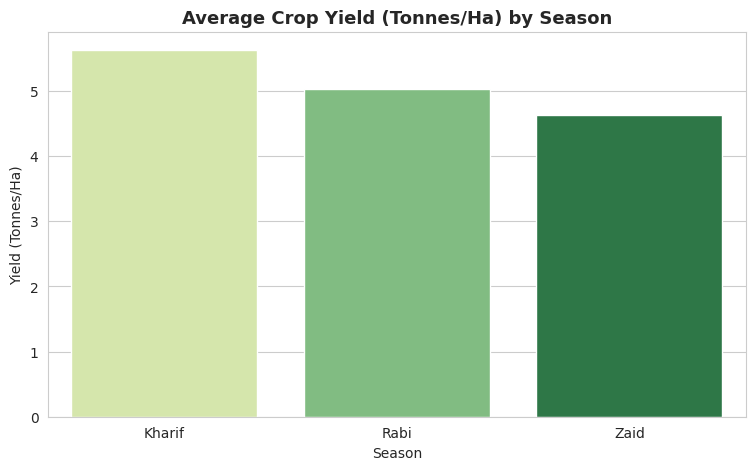

In [126]:
# Bar chart: Average Yield by Season
plt.figure()
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", estimator=np.mean,
            palette="YlGn", errorbar=None, hue="Season")
plt.title("Average Crop Yield (Tonnes/Ha) by Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

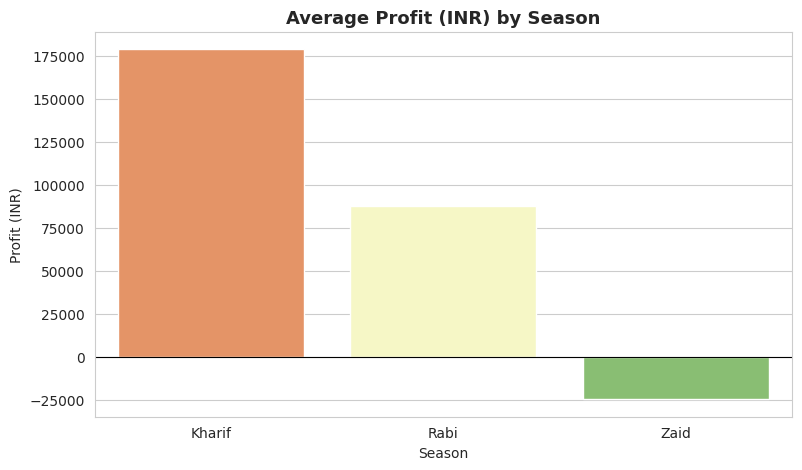

In [127]:
# Bar chart: Average Profit by Season
plt.figure()
sns.barplot(data=df, x="Season", y="Profit_INR", estimator=np.mean,
            palette="RdYlGn", errorbar=None, hue="Season")
plt.title("Average Profit (INR) by Season")
plt.ylabel("Profit (INR)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

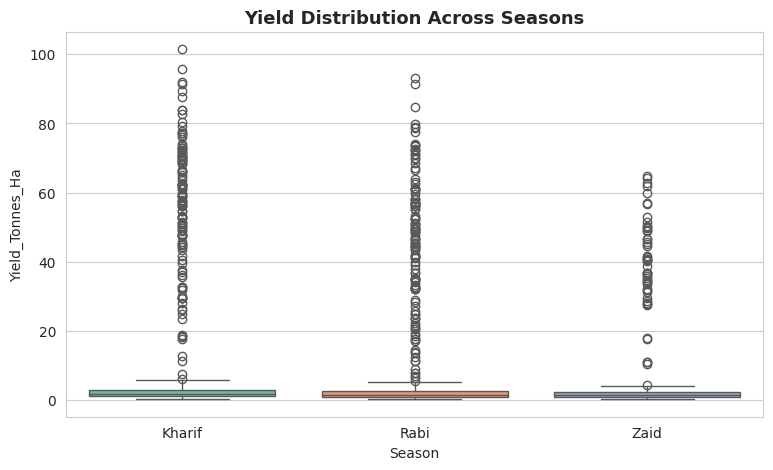

In [128]:
# Boxplot: Yield distribution by season (shows spread, not just average)
plt.figure()
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2", hue= "Season")
plt.title("Yield Distribution Across Seasons")
plt.show()

In [129]:
# ---------------------------------------------------------------
# STEP 4b: Statistical significance testing (ANOVA)
# ---------------------------------------------------------------
# The charts above show visual differences between seasons, but to claim a
# difference is "significant" we need a statistical test, not just eyeballing
# a bar chart. One-way ANOVA tests whether the mean of a metric differs
# significantly across the 3 season groups (Kharif / Rabi / Zaid).
#
# H0 (null hypothesis): the mean is the same across all seasons.
# H1 (alt hypothesis): at least one season's mean is different.
# We reject H0 if p-value < 0.05.

from scipy import stats

def run_anova(column):
    groups = [df[df["Season"] == s][column].dropna() for s in df["Season"].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    result = "Significant difference" if p_value < 0.05 else "No significant difference"
    print(f"{column:30s} F={f_stat:8.2f}  p={p_value:.4f}  -> {result}")
    return f_stat, p_value

print("One-way ANOVA: does this metric differ significantly across seasons?")
print("-" * 75)
anova_cols = ["Yield_Tonnes_Ha", "Profit_INR", "Total_Cost_INR", "Revenue_INR",
              "Water_Used_m3", "Rainfall_mm", "Avg_Temperature_C",
              "Disease_Pest_Risk_pct"]

anova_results = {}
for col in anova_cols:
    anova_results[col] = run_anova(col)

One-way ANOVA: does this metric differ significantly across seasons?
---------------------------------------------------------------------------
Yield_Tonnes_Ha                F=    1.55  p=0.2116  -> No significant difference
Profit_INR                     F=   34.29  p=0.0000  -> Significant difference
Total_Cost_INR                 F=    2.84  p=0.0584  -> No significant difference
Revenue_INR                    F=   24.89  p=0.0000  -> Significant difference
Water_Used_m3                  F=    2.47  p=0.0850  -> No significant difference
Rainfall_mm                    F= 3449.40  p=0.0000  -> Significant difference
Avg_Temperature_C              F= 2678.74  p=0.0000  -> Significant difference
Disease_Pest_Risk_pct          F= 1049.47  p=0.0000  -> Significant difference


In [130]:
# Pairwise comparison (Tukey HSD) for the metric most relevant to the
# project — Yield — to see WHICH specific season pairs differ significantly,
# not just that some difference exists somewhere.
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_yield = pairwise_tukeyhsd(endog=df["Yield_Tonnes_Ha"], groups=df["Season"], alpha=0.05)
print("Tukey HSD post-hoc test — Yield_Tonnes_Ha, pairwise season comparison:")
print(tukey_yield)

Tukey HSD post-hoc test — Yield_Tonnes_Ha, pairwise season comparison:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Kharif   Rabi   -0.591 0.3984 -1.6615 0.4795  False
Kharif   Zaid  -0.9906 0.2586 -2.4693 0.4882  False
  Rabi   Zaid  -0.3996 0.8057 -1.8956 1.0964  False
---------------------------------------------------


In [131]:
tukey_profit = pairwise_tukeyhsd(endog=df["Profit_INR"], groups=df["Season"], alpha=0.05)
print("Tukey HSD post-hoc test — Profit_INR, pairwise season comparison:")
print(tukey_profit)

Tukey HSD post-hoc test — Profit_INR, pairwise season comparison:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------


In [132]:
# ---------------------------------------------------------------
# STEP 5: Environmental conditions across seasons
# ---------------------------------------------------------------
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
            "Sunlight_Hours_Day", "Soil_Moisture_pct"]

env_summary = df.groupby("Season")[env_cols].mean().round(2)
print("Average environmental conditions by season:")
display(env_summary)

Average environmental conditions by season:


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


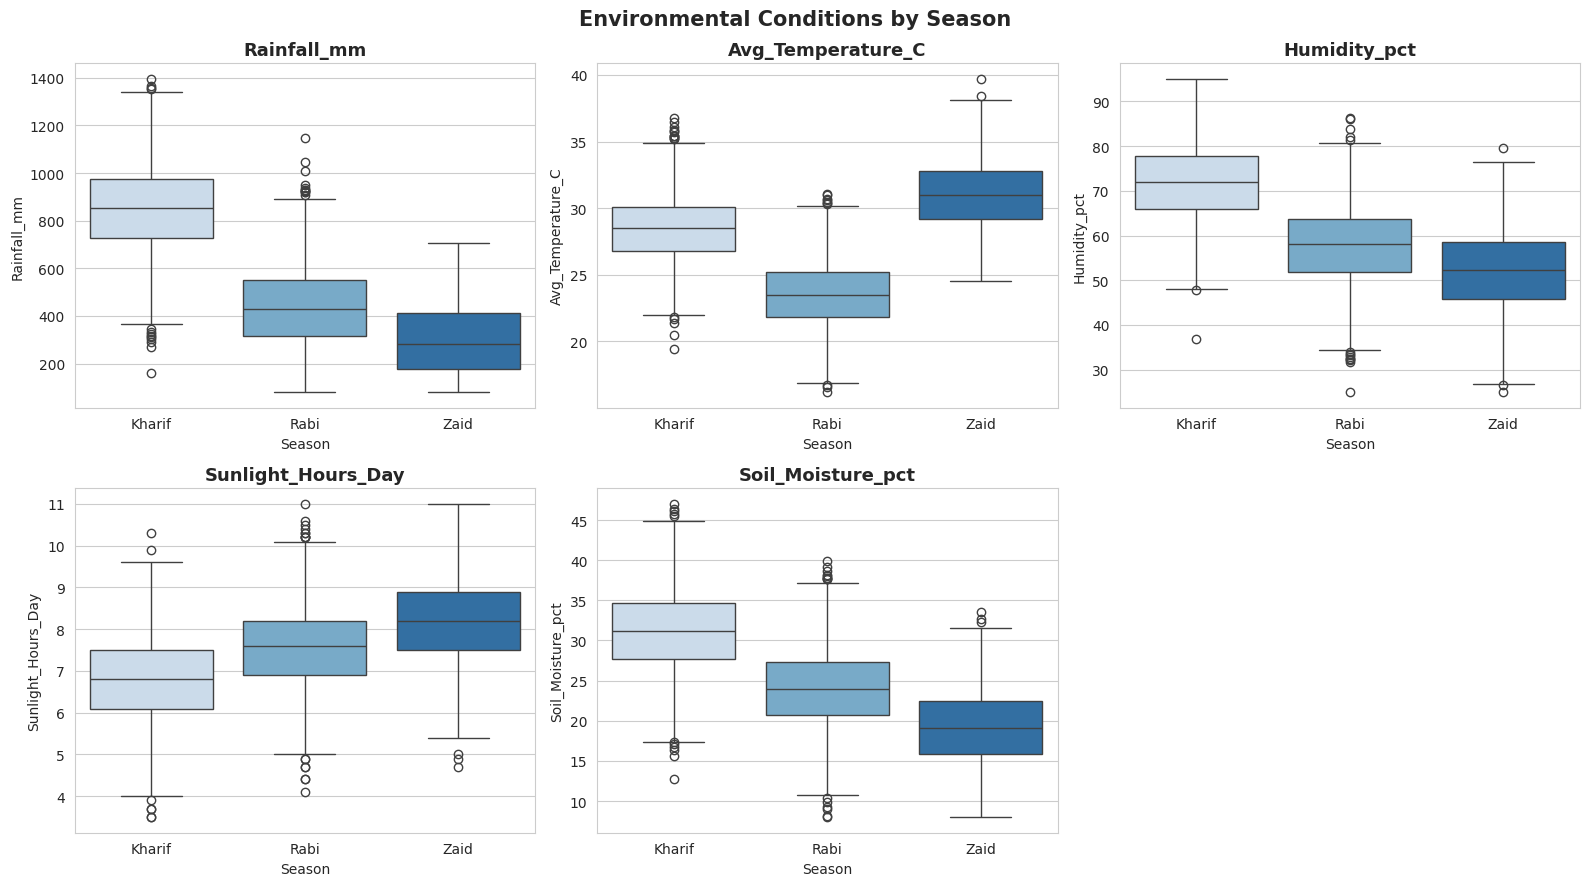

In [133]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x="Season", y=col, ax=axes[i], palette="Blues", hue="Season")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.suptitle("Environmental Conditions by Season", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [134]:
# ---------------------------------------------------------------
# STEP 6: Resource usage across seasons
# ---------------------------------------------------------------
resource_cols = ["Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
                  "Water_Efficiency_t_per_1000m3"]

resource_summary = df.groupby("Season")[resource_cols].mean().round(2)
print("Average resource usage by season:")
display(resource_summary)

Average resource usage by season:


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


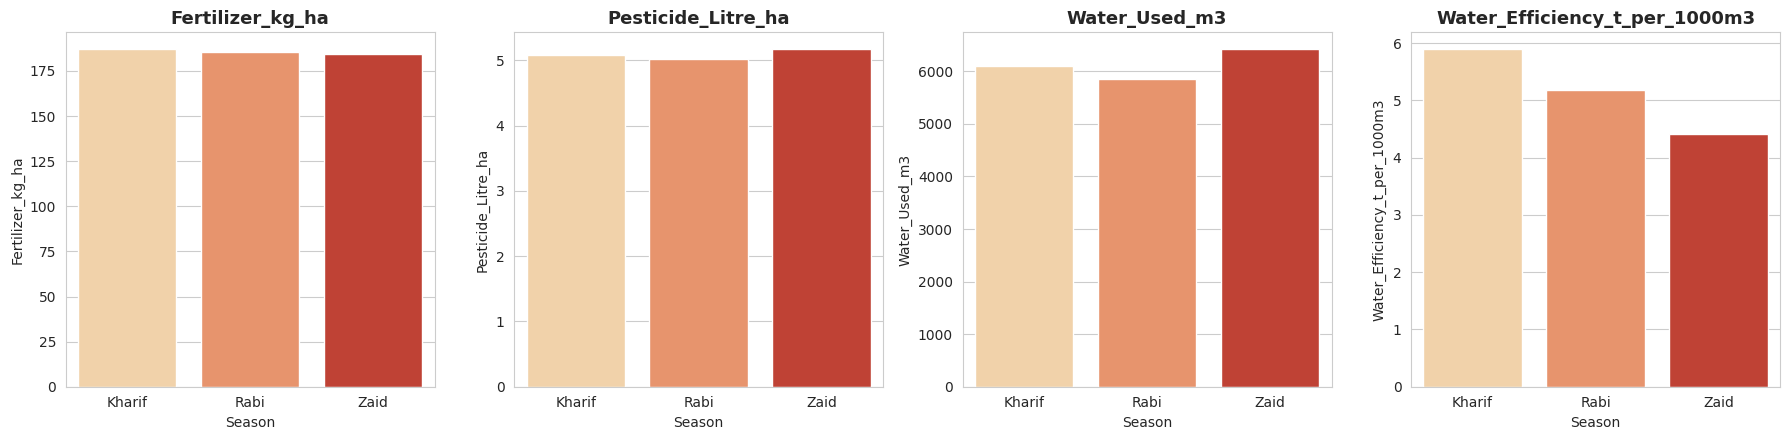

In [135]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for i, col in enumerate(resource_cols):
    sns.barplot(data=df, x="Season", y=col, ax=axes[i], palette="OrRd",
                estimator=np.mean, errorbar=None, hue="Season")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [136]:
# ---------------------------------------------------------------
# STEP 7: Economic performance across seasons
# ---------------------------------------------------------------
econ_cols = ["Total_Cost_INR", "Revenue_INR", "Profit_INR", "Profit_Margin_pct"]

econ_summary = df.groupby("Season")[econ_cols].mean().round(2)
print("Average economic performance by season:")
display(econ_summary)

# What fraction of farms are profitable in each season?
profitable_pct = df.groupby("Season").apply(
    lambda x: (x["Profit_INR"] > 0).mean() * 100
).round(1)
print("\nPercentage of profitable farms by season:")
print(profitable_pct)

Average economic performance by season:


,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.41,710719.06,178914.65,-38.64
Rabi,513836.58,601526.05,87689.47,-44.27
Zaid,543976.73,519171.90,-24804.82,-69.35



Percentage of profitable farms by season:
Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
dtype: float64


/tmp/ipykernel_543/200658929.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profitable_pct = df.groupby("Season").apply(


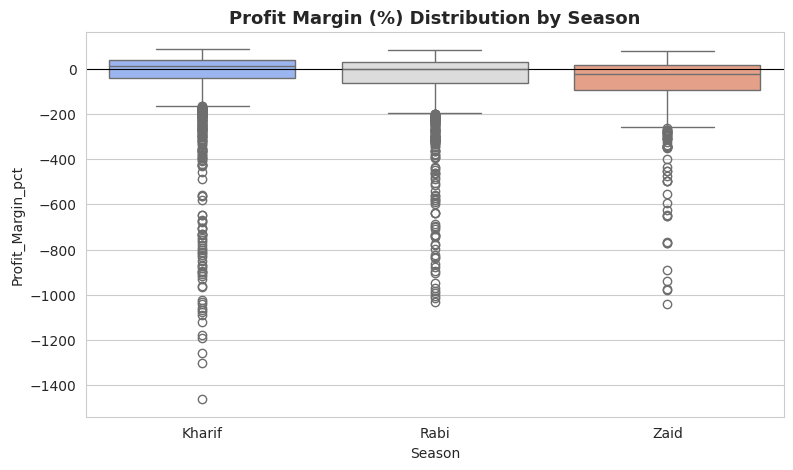

In [137]:
plt.figure()
sns.boxplot(data=df, x="Season", y="Profit_Margin_pct", palette="coolwarm", hue="Season")
plt.title("Profit Margin (%) Distribution by Season")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

Average yield (Tonnes/Ha) — Crop x Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


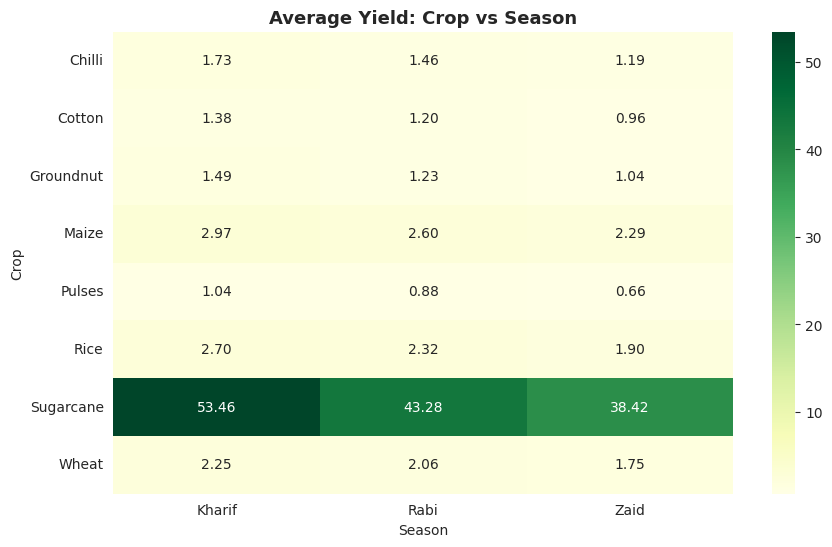

In [138]:
# ---------------------------------------------------------------
# STEP 8: Crop-wise performance within each season
# ---------------------------------------------------------------
crop_season_yield = df.pivot_table(
    index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean"
).round(2)
print("Average yield (Tonnes/Ha) — Crop x Season:")
display(crop_season_yield)

plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGn")
plt.title("Average Yield: Crop vs Season")
plt.show()

Average profit (INR) — Crop x Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


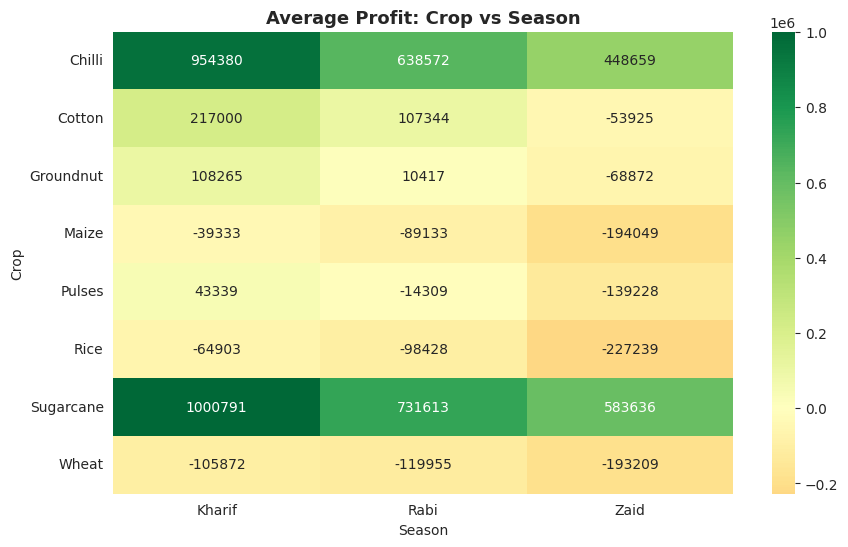

In [139]:
crop_season_profit = df.pivot_table(
    index="Crop", columns="Season", values="Profit_INR", aggfunc="mean"
).round(0)
print("Average profit (INR) — Crop x Season:")
display(crop_season_profit)

plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit: Crop vs Season")
plt.show()

Yield & water efficiency by season and irrigation method:


Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
Season Irrigation_Method                                                
Kharif Drip                          7.26                           6.80
       Flood                         4.98                           3.64
       Rainfed                       5.70                           8.85
       Sprinkler                     4.66                           4.62
Rabi   Drip                          6.11                           6.05
       Flood                         5.06                           3.48
       Rainfed                       3.93                           6.87
       Sprinkler                     5.31                           4.64
Zaid   Drip                          5.85                           5.30
       Flood                         3.98                           2.73
       Rainfed                       3.06                           5.48
       Sprinkler                     6.13                           4.86

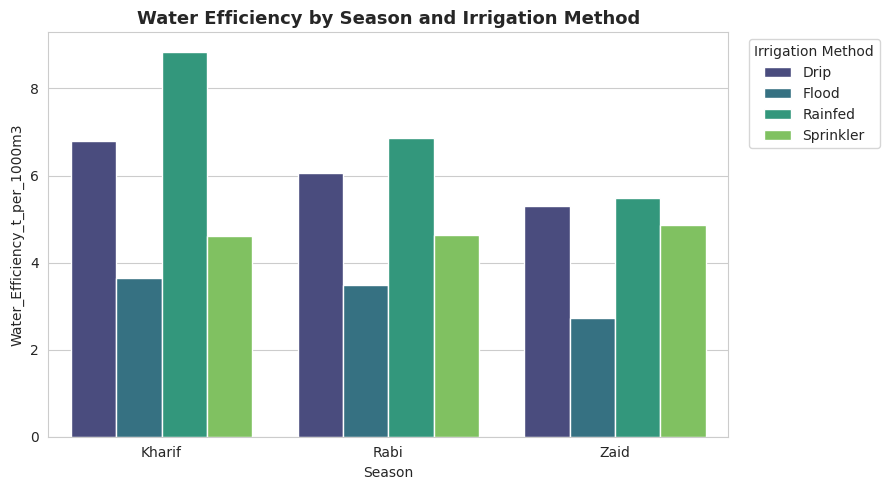

In [140]:
# ---------------------------------------------------------------
# STEP 9: Irrigation method effectiveness by season
# ---------------------------------------------------------------
irrigation_summary = df.groupby(["Season", "Irrigation_Method"])[
    ["Yield_Tonnes_Ha", "Water_Efficiency_t_per_1000m3"]
].mean().round(2)
print("Yield & water efficiency by season and irrigation method:")
display(irrigation_summary)

plt.figure()
sns.barplot(data=df, x="Season", y="Water_Efficiency_t_per_1000m3",
            hue="Irrigation_Method", palette="viridis", errorbar=None)
plt.title("Water Efficiency by Season and Irrigation Method")
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Average yield by state and season:


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.44,4.06
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.47
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


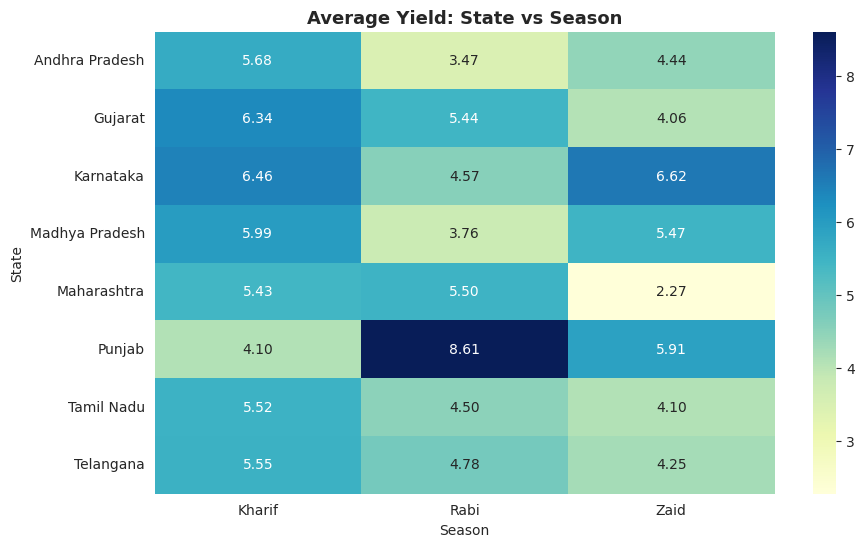

In [141]:
# ---------------------------------------------------------------
# STEP 10: State-wise seasonal patterns
# ---------------------------------------------------------------
state_season_yield = df.pivot_table(
    index="State", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean"
).round(2)
print("Average yield by state and season:")
display(state_season_yield)

plt.figure(figsize=(10, 6))
sns.heatmap(state_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield: State vs Season")
plt.show()

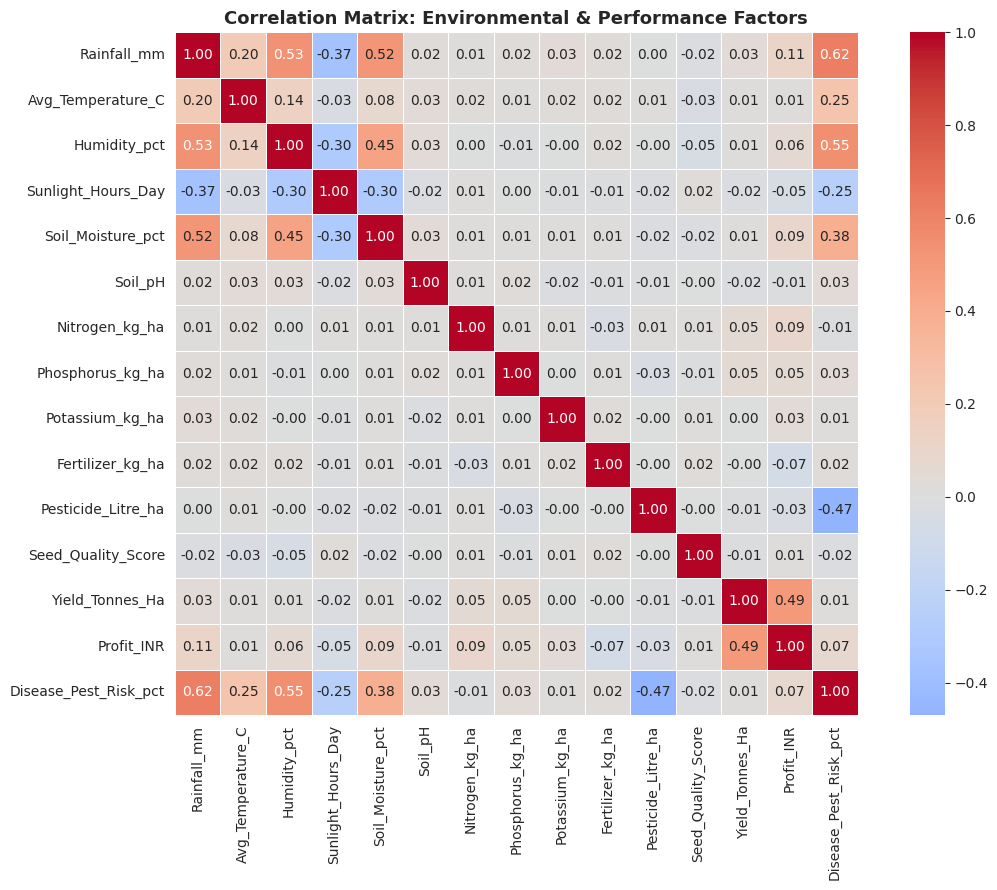

In [142]:
# ---------------------------------------------------------------
# STEP 11: Relationships between environmental conditions and yield
# ---------------------------------------------------------------
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
             "Sunlight_Hours_Day", "Soil_Moisture_pct", "Soil_pH",
             "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
             "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
             "Yield_Tonnes_Ha", "Profit_INR", "Disease_Pest_Risk_pct"]

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix: Environmental & Performance Factors")
plt.tight_layout()
plt.show()

In [143]:
# Correlation of every factor specifically with Yield, sorted
yield_corr = corr_matrix["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(
    ascending=False
)
print("Correlation of factors with Yield (strongest to weakest):")
print(yield_corr)

Correlation of factors with Yield (strongest to weakest):
Profit_INR               0.49
Nitrogen_kg_ha           0.05
Phosphorus_kg_ha         0.05
Rainfall_mm              0.03
Humidity_pct             0.01
Avg_Temperature_C        0.01
Soil_Moisture_pct        0.01
Disease_Pest_Risk_pct    0.01
Fertilizer_kg_ha        -0.00
Potassium_kg_ha          0.00
Seed_Quality_Score      -0.01
Pesticide_Litre_ha      -0.01
Soil_pH                 -0.02
Sunlight_Hours_Day      -0.02
Name: Yield_Tonnes_Ha, dtype: float64


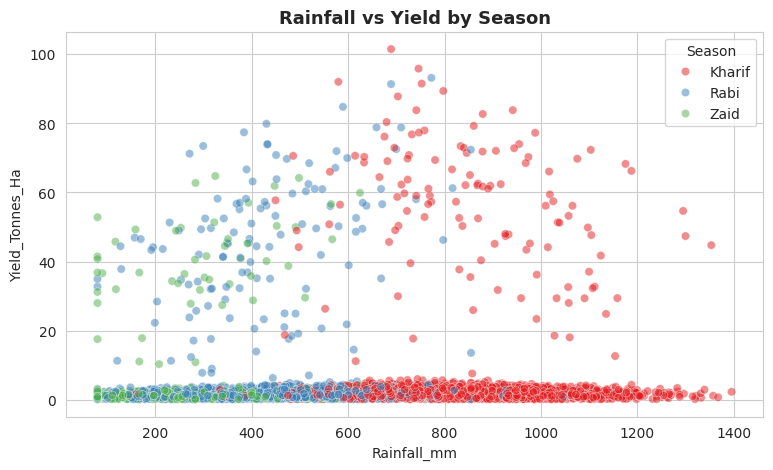

In [144]:
# Scatter plot: Rainfall vs Yield, colored by season
plt.figure()
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",
                 alpha=0.5, palette="Set1")
plt.title("Rainfall vs Yield by Season")
plt.show()

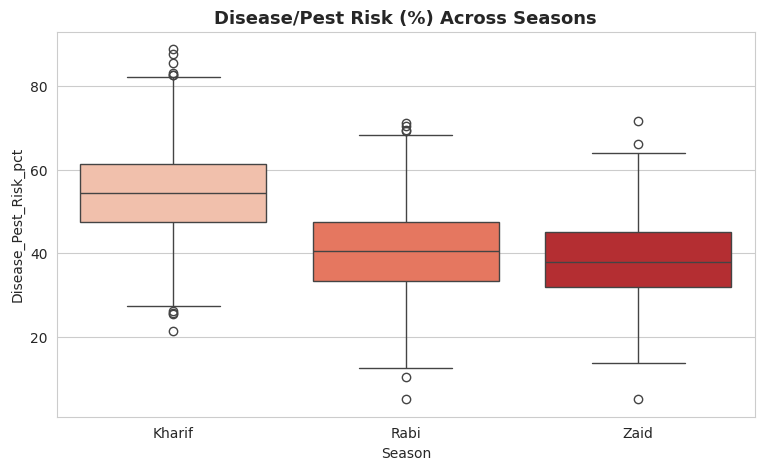

         mean  median   max
Season                     
Kharif  54.47    54.5  88.9
Rabi    40.48    40.6  71.2
Zaid    38.22    37.9  71.6


In [145]:
# ---------------------------------------------------------------
# STEP 12: Disease / pest risk across seasons
# ---------------------------------------------------------------
plt.figure()
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", palette="Reds", hue="Season")
plt.title("Disease/Pest Risk (%) Across Seasons")
plt.show()

risk_summary = df.groupby("Season")["Disease_Pest_Risk_pct"].agg(
    ["mean", "median", "max"]
).round(2)
print(risk_summary)

In [146]:
# ---------------------------------------------------------------
# STEP 13: Identifying unusual / unexpected patterns
# ---------------------------------------------------------------
# Farms with high yield but negative profit (cost overruns)
high_yield_loss = df[(df["Yield_Tonnes_Ha"] > df["Yield_Tonnes_Ha"].quantile(0.75)) &
                      (df["Profit_INR"] < 0)]
print(f"Farms with high yield (top 25%) but negative profit: {len(high_yield_loss)}")
print(high_yield_loss.groupby("Season").size())

Farms with high yield (top 25%) but negative profit: 209
Season
Kharif    98
Rabi      85
Zaid      26
dtype: int64


In [147]:
# Farms with very low rainfall but still high yield (possibly irrigation-driven)
low_rain_high_yield = df[(df["Rainfall_mm"] < df["Rainfall_mm"].quantile(0.25)) &
                          (df["Yield_Tonnes_Ha"] > df["Yield_Tonnes_Ha"].quantile(0.75))]
print(f"Farms with low rainfall but high yield: {len(low_rain_high_yield)}")
print(low_rain_high_yield["Irrigation_Method"].value_counts())

Farms with low rainfall but high yield: 149
Irrigation_Method
Drip         49
Flood        39
Sprinkler    36
Rainfed      25
Name: count, dtype: int64


In [148]:
# ---------------------------------------------------------------
# STEP 14: Summary of key seasonal insights
# ---------------------------------------------------------------
# This section prints an auto-generated, data-driven summary. Review these
# numbers and use them to write your own conclusions in words in the report.

best_yield_season = season_summary["Yield_Tonnes_Ha"].idxmax()
best_profit_season = season_summary["Profit_INR"].idxmax()
worst_profit_season = season_summary["Profit_INR"].idxmin()
highest_water_use_season = season_summary["Water_Used_m3"].idxmax()
most_efficient_water_season = season_summary["Water_Efficiency_t_per_1000m3"].idxmax()
highest_risk_season = risk_summary["mean"].idxmax()

print("KEY SEASONAL INSIGHTS")
print("-" * 50)
print(f"Highest average yield        : {best_yield_season}")
print(f"Highest average profit       : {best_profit_season}")
print(f"Lowest average profit        : {worst_profit_season}")
print(f"Highest water consumption    : {highest_water_use_season}")
print(f"Most water-efficient season  : {most_efficient_water_season}")
print(f"Highest disease/pest risk    : {highest_risk_season}")
print(f"\nStrongest positive driver of yield : {yield_corr.index[0]} (r={yield_corr.iloc[0]:.2f})")
print(f"Strongest negative driver of yield : {yield_corr.index[-1]} (r={yield_corr.iloc[-1]:.2f})")

print("\nStatistically significant seasonal differences (ANOVA, p < 0.05):")
sig_metrics = [col for col, (f, p) in anova_results.items() if p < 0.05]
non_sig_metrics = [col for col, (f, p) in anova_results.items() if p >= 0.05]
print("  Significant   :", sig_metrics if sig_metrics else "None")
print("  Not significant:", non_sig_metrics if non_sig_metrics else "None")

KEY SEASONAL INSIGHTS
--------------------------------------------------
Highest average yield        : Kharif
Highest average profit       : Kharif
Lowest average profit        : Zaid
Highest water consumption    : Zaid
Most water-efficient season  : Kharif
Highest disease/pest risk    : Kharif

Strongest positive driver of yield : Profit_INR (r=0.49)
Strongest negative driver of yield : Sunlight_Hours_Day (r=-0.02)

Statistically significant seasonal differences (ANOVA, p < 0.05):
  Significant   : ['Profit_INR', 'Revenue_INR', 'Rainfall_mm', 'Avg_Temperature_C', 'Disease_Pest_Risk_pct']
  Not significant: ['Yield_Tonnes_Ha', 'Total_Cost_INR', 'Water_Used_m3']


In [149]:
# ---------------------------------------------------------------
# STEP 15: Save the cleaned dataset (optional, for reuse)
# ---------------------------------------------------------------
df.to_csv("cleaned_seasonal_agriculture_dataset.csv", index=False)
print("Cleaned dataset saved as cleaned_seasonal_agriculture_dataset.csv")

Cleaned dataset saved as cleaned_seasonal_agriculture_dataset.csv


## Conclusions & Recommendations (write-up)

Use the printed summaries and charts above to fill in your own written
conclusions here, for example:

- **Which season performs best overall** (yield, profit, water efficiency)
  and why, based on the environmental and resource data.
- **Which season carries the most risk** (disease/pest, cost overruns,
  negative profit) and what might be driving it.
- **Which factors matter most for yield** (from the correlation analysis)
  and how farmers could act on that (e.g. irrigation choice, fertilizer
  levels, sowing timing).
- **State/crop-specific patterns** worth highlighting from the heatmaps.
- **Recommendations** for seasonal agricultural planning — e.g. resource
  allocation, crop selection per season, irrigation method by season.

## Additional Student-Driven Analysis

The three analyses below go beyond the guided steps above. Each investigates a
question that wasn't already answered, and each is explained in terms of why
it matters for understanding seasonal agricultural performance.

### Student Analysis 1: Does farm size affect profitability, and does this relationship change by season?

**Question:** Do larger farms achieve better profit margins than smaller farms,
and is this relationship consistent across seasons, or does farm size matter
more in some seasons than others?

**Why this is relevant:** The project asks us to investigate resource usage
and economic performance across seasons. Farm size is a resource variable
that hasn't been examined yet, and it directly affects planning — if larger
farms are consistently more (or less) profitable, that has real implications
for how land should be allocated season to season.

Average profit margin (%) by farm size:
Farm_Size_Bucket
Small (<2ha)         -46.24
Medium (2-5ha)       -49.30
Large (5-10ha)       -40.98
Very Large (>10ha)   -47.30
Name: Profit_Margin_pct, dtype: float64

Average profit margin (%) by farm size, within each season:
Season  Farm_Size_Bucket  
Kharif  Small (<2ha)         -35.00
        Medium (2-5ha)       -48.32
        Large (5-10ha)       -28.62
        Very Large (>10ha)   -42.67
Rabi    Small (<2ha)         -59.79
        Medium (2-5ha)       -45.49
        Large (5-10ha)       -39.56
        Very Large (>10ha)   -43.84
Zaid    Small (<2ha)         -43.02
        Medium (2-5ha)       -63.94
        Large (5-10ha)       -77.90
        Very Large (>10ha)   -70.34
Name: Profit_Margin_pct, dtype: float64


/tmp/ipykernel_543/1380652459.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_profit = df.groupby("Farm_Size_Bucket")["Profit_Margin_pct"].mean().round(2)
/tmp/ipykernel_543/1380652459.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_season_profit = df.groupby(["Season", "Farm_Size_Bucket"])["Profit_Margin_pct"].mean().round(2)


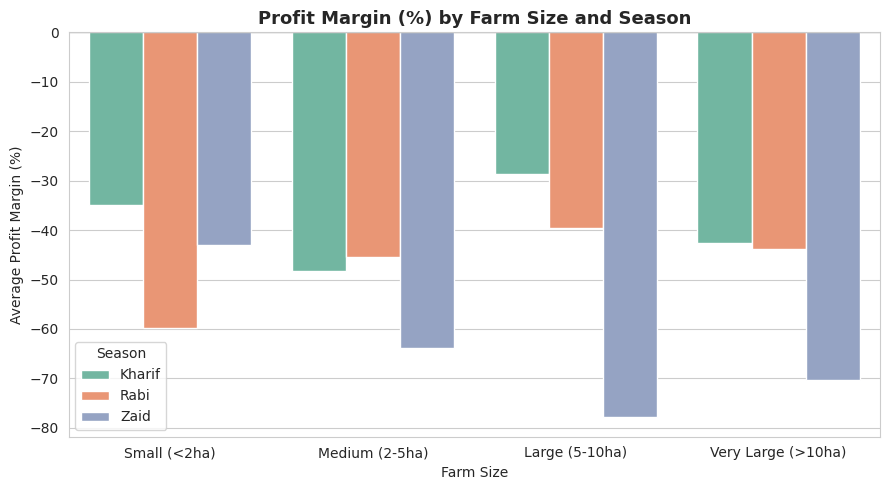

In [150]:
# Student Analysis 1: Farm size vs profitability

df["Farm_Size_Bucket"] = pd.cut(
    df["Farm_Area_Hectares"],
    bins=[0, 2, 5, 10, 100],
    labels=["Small (<2ha)", "Medium (2-5ha)", "Large (5-10ha)", "Very Large (>10ha)"]
)

size_profit = df.groupby("Farm_Size_Bucket")["Profit_Margin_pct"].mean().round(2)
print("Average profit margin (%) by farm size:")
print(size_profit)

size_season_profit = df.groupby(["Season", "Farm_Size_Bucket"])["Profit_Margin_pct"].mean().round(2)
print("\nAverage profit margin (%) by farm size, within each season:")
print(size_season_profit)

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Farm_Size_Bucket", y="Profit_Margin_pct", hue="Season",
            palette="Set2", errorbar=None)
plt.title("Profit Margin (%) by Farm Size and Season")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average Profit Margin (%)")
plt.xlabel("Farm Size")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Interpretation:** Profit margin is negative across every farm size bucket,
so farm size alone does not turn a farm profitable. There is a mild trend of
Large farms (5-10ha) doing relatively better than other sizes overall, but the
effect flips by season — in Zaid, Large and Very Large farms have the worst
margins of all buckets, while in Kharif they have the best. This suggests farm
size is not a reliable profitability lever on its own; its effect depends
heavily on which season the farm is operating in.

### Student Analysis 2: Does fertilizer produce the same yield return in every season?

**Question:** For a similar amount of fertilizer applied, does yield return
differ by season? In other words, is fertilizer "worth more" in some seasons
than others?

**Why this is relevant:** The project asks us to examine resource usage
across seasons. Earlier steps looked at *how much* fertilizer is used per
season, but not how *effectively* it converts into yield. This matters
directly for cost-efficient seasonal planning — if fertilizer is less
effective in a season, farmers might be better off reducing dosage or
switching resources there instead.

Average fertilizer applied and fertilizer efficiency (yield per kg) by season:
        Fertilizer_kg_ha  Fertilizer_Efficiency
Season                                         
Kharif          187.0780                 0.0348
Rabi            185.4071                 0.0308
Zaid            184.6380                 0.0274


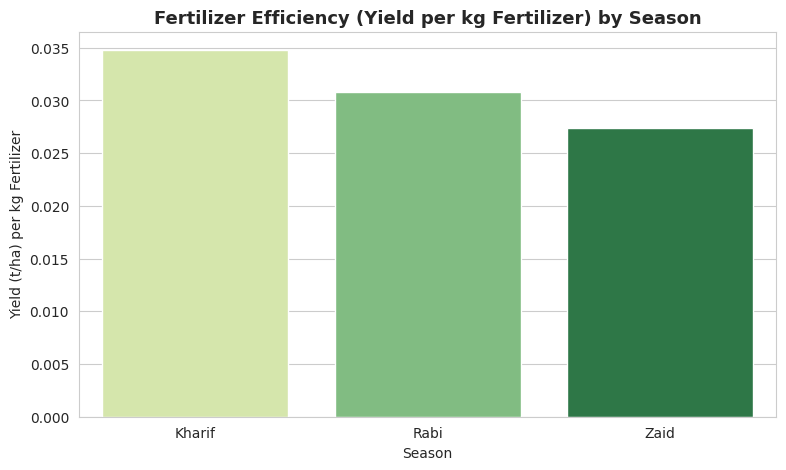

In [151]:
# Student Analysis 2: Fertilizer efficiency by season (yield per kg of fertilizer)

df["Fertilizer_Efficiency"] = df["Yield_Tonnes_Ha"] / df["Fertilizer_kg_ha"]

fert_summary = df.groupby("Season")[["Fertilizer_kg_ha", "Fertilizer_Efficiency"]].mean().round(4)
print("Average fertilizer applied and fertilizer efficiency (yield per kg) by season:")
print(fert_summary)

plt.figure()
sns.barplot(data=df, x="Season", y="Fertilizer_Efficiency", palette="YlGn",
            estimator=np.mean, errorbar=None, hue="Season")
plt.title("Fertilizer Efficiency (Yield per kg Fertilizer) by Season")
plt.ylabel("Yield (t/ha) per kg Fertilizer")
plt.show()

**Interpretation:** Fertilizer application amounts are almost identical across
the three seasons (184-187 kg/ha), but the yield returned per kg of fertilizer
is highest in Kharif and lowest in Zaid. This means the *same* fertilizer
investment produces less yield in Zaid — likely because the harsher heat and
lower soil moisture in Zaid (seen in Step 5) limit how much crops can actually
use the nutrients applied, not because less fertilizer is used there.

### Student Analysis 3: Which crops are consistently profitable across all seasons, and which consistently lose money?

**Question:** Beyond average profit, which crops show *stable* profitability
across all three seasons (low risk), and which are consistently unprofitable
regardless of season?

**Why this is relevant:** Average profit (already shown in Step 8) can hide
risk. A crop with high average profit but wild swings between seasons is
risky to plan around, while a crop that is always profitable — even by a
smaller margin — may be a safer long-term recommendation. This directly
supports the project's goal of evidence-based agricultural planning.

Profit stability across seasons (Coefficient of Variation, lower = more stable):
Crop
Sugarcane    0.274
Wheat        0.336
Chilli       0.375
Rice         0.658
Maize        0.735
Cotton       1.512
Pulses       2.541
Groundnut    5.344
dtype: float64

% of farms that are profitable, by crop:
Crop
Wheat        25.9
Rice         33.6
Maize        36.3
Pulses       50.8
Groundnut    59.2
Cotton       65.4
Chilli       82.0
Sugarcane    88.5
dtype: float64


/tmp/ipykernel_543/1283337916.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  crop_profitable_pct = df.groupby("Crop").apply(lambda x: (x["Profit_INR"] > 0).mean() * 100).round(1).sort_values()


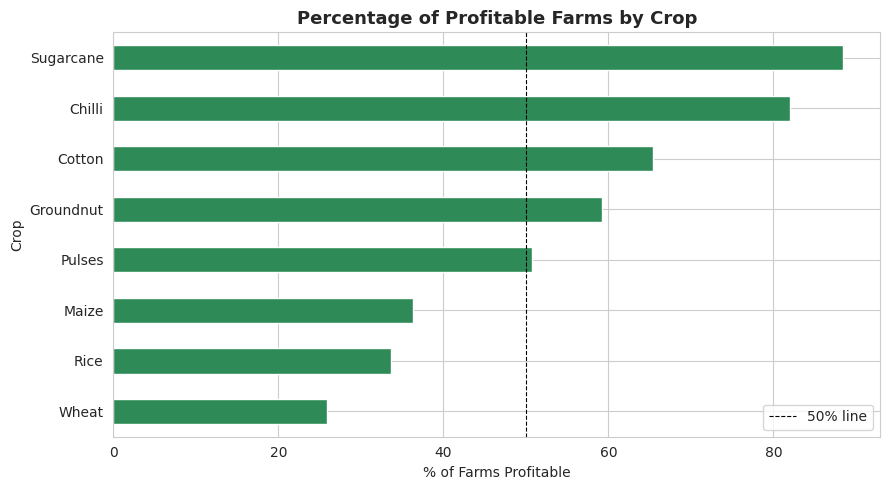

In [152]:
# Student Analysis 3: Crop profit stability across seasons + which crops are reliably unprofitable

crop_season_profit_full = df.pivot_table(index="Crop", columns="Season", values="Profit_INR", aggfunc="mean")

# Coefficient of variation across the 3 seasons (lower = more stable)
cv = (crop_season_profit_full.std(axis=1) / crop_season_profit_full.mean(axis=1).abs()).sort_values()
print("Profit stability across seasons (Coefficient of Variation, lower = more stable):")
print(cv.round(3))

# % of farms that are profitable, by crop (across all seasons combined)
crop_profitable_pct = df.groupby("Crop").apply(lambda x: (x["Profit_INR"] > 0).mean() * 100).round(1).sort_values()
print("\n% of farms that are profitable, by crop:")
print(crop_profitable_pct)

plt.figure(figsize=(9, 5))
crop_profitable_pct.plot(kind="barh", color="seagreen")
plt.title("Percentage of Profitable Farms by Crop")
plt.xlabel("% of Farms Profitable")
plt.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50% line")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Sugarcane and Chilli are both the most profitable on
average *and* the most stable (lowest CV), with 88.5% and 82.0% of their
farms profitable respectively — a genuinely low-risk recommendation. At the
other end, Wheat is profitable in only 25.9% of farms and Rice in 33.6%,
meaning these crops lose money more often than not, regardless of season.
This is a stronger, more decision-useful finding than average profit alone,
since it separates "profitable on average because of a few big wins" from
"reliably profitable".

## Key Insights

**1. Observation:** Kharif has the highest average yield and profit of the three seasons.
**Evidence:** Season summary in Step 4 (bar charts of Yield and Profit by Season).
**Interpretation:** Kharif's higher rainfall and moderate temperature (Step 5) likely create more favorable growing conditions overall.
**Limitation:** This is an average across all crops and states — it does not mean every individual farm or crop performs best in Kharif.

**2. Observation:** Despite visible differences in average yield across seasons, ANOVA shows Yield does NOT differ significantly (p = 0.21), while Profit, Revenue, Rainfall, Temperature, and Disease Risk DO differ significantly (p < 0.05).
**Evidence:** Step 4b, one-way ANOVA results.
**Interpretation:** Season affects economic outcomes and environmental conditions more reliably than it affects yield itself — yield variation is likely driven more by crop type or farm-level factors than by season alone.
**Limitation:** ANOVA tells us a difference exists, not what causes it — it does not identify which specific factor drives the profit difference.

**3. Observation:** Overall, only 50.8% of farms in the dataset are profitable, with an average profit margin of -45.5%.
**Evidence:** Profitability calculation across the full dataset (Student Analysis 3, and Step 7 profit margin summary).
**Interpretation:** Financial risk is a bigger concern in this dataset than yield or environmental risk — roughly half of all farming activity recorded here is losing money.
**Limitation:** The dataset does not explain cost structure in detail (e.g. labor, land rent), so we cannot say definitively why costs are outweighing revenue this often.

**4. Observation:** No single environmental factor (rainfall, temperature, soil pH, NPK levels) shows a strong individual correlation with yield — all correlations are below 0.05 in magnitude.
**Evidence:** Step 11 correlation matrix.
**Interpretation:** Yield likely results from a combination of interacting factors rather than one dominant driver, which is consistent with real-world agriculture.
**Limitation:** Correlation only measures linear relationships — a factor could still matter through a non-linear or combined effect that this analysis wouldn't detect.

**5. Observation:** Drip irrigation gives the highest water efficiency in all three seasons, while Flood irrigation is the least efficient in all three seasons.
**Evidence:** Step 9 irrigation method comparison.
**Interpretation:** Drip irrigation converts water into yield more effectively regardless of season, making it a consistently good choice.
**Limitation:** The dataset doesn't include the cost of installing/maintaining drip irrigation infrastructure, so efficiency alone doesn't capture the full economic picture of switching methods.

**6. Observation:** Zaid has the hottest average temperature (31°C), lowest rainfall (299mm) and lowest soil moisture (19%) of the three seasons, and also the lowest fertilizer efficiency and lowest average profit.
**Evidence:** Step 5 environmental summary, Student Analysis 2 (fertilizer efficiency), Step 7 economic summary.
**Interpretation:** Zaid's harsher, drier conditions likely limit how effectively crops can use applied resources like fertilizer, contributing to its weaker economic performance.
**Limitation:** This is an association across many observations, not a controlled experiment — we can't confirm heat/dryness directly *causes* the lower fertilizer efficiency without isolating other variables.

**7. Observation:** Sugarcane and Chilli are both the most profitable (highest average) and most stable (lowest season-to-season variation) crops, while Wheat and Rice are profitable in less than 34% of farms.
**Evidence:** Student Analysis 3 (crop profit stability, % profitable by crop).
**Interpretation:** Some crops are reliable performers across all seasons, while others carry high financial risk regardless of season — crop choice matters at least as much as season choice.
**Limitation:** Profitability here reflects this dataset's price and cost assumptions; real-world market price volatility could change these numbers significantly season to season.

**8. Observation:** 209 farms had yield in the top 25% but still recorded a financial loss, concentrated mostly in Kharif (98) and Rabi (85), with far fewer in Zaid (26).
**Evidence:** Step 13, high-yield-but-loss farm analysis.
**Interpretation:** High yield does not guarantee profitability — cost overruns appear to be a meaningful, season-linked problem, especially in Kharif and Rabi.
**Limitation:** The dataset doesn't break down which specific costs (fertilizer, labor, irrigation, pesticide) are responsible, so we can only flag the pattern, not its root cause.

## Recommendations

Based only on the evidence found in this dataset:

1. **Prioritize Drip irrigation over Flood irrigation, especially in Zaid.** Drip consistently shows the highest water efficiency across all seasons, while Flood is consistently the worst (Insight 5). This is the most directly actionable finding in the dataset.

2. **Treat Kharif and Rabi as the primary planning seasons**, since they show the highest yield, revenue, and profit on average (Insight 1). Zaid should be approached more cautiously given its lower fertilizer efficiency and profit (Insight 6).

3. **Favor Sugarcane and Chilli where feasible**, since they are both high-profit and low-risk (stable) across all seasons (Insight 7). Wheat and Rice, while common crops, show high financial risk in this dataset and may need cost review before being scaled up.

4. **Investigate cost management for high-yield farms specifically**, since a meaningful share of farms (209) achieve strong yield but still lose money (Insight 8). This points to costs, not farming skill, as the likely issue — worth a focused cost audit, especially in Kharif and Rabi.

5. **Don't rely on farm size as a profitability strategy.** Larger farms are not consistently more profitable, and the effect actually reverses in Zaid (Student Analysis 1) — resource allocation decisions should be season-specific, not size-based.

**Important caveat:** These recommendations are based on patterns and associations observed in this dataset. They should be validated against real field conditions, current market prices, and local expert input before being applied — the dataset does not establish causation, and local factors not captured here (soil variation, labor costs, local market access) could change what's optimal for a specific farm.

## Conclusion

This analysis of 4,000 farm records across 3 seasons, 8 states, and 8 crops set out
to understand how seasonal variation affects agricultural performance.

**What the dataset revealed:** Seasonal differences are real but uneven —
economic outcomes (profit, revenue), environmental conditions (rainfall,
temperature), and disease/pest risk differ significantly across seasons, but
yield itself does not differ as significantly as the visual charts might
suggest (confirmed via ANOVA). Kharif consistently emerged as the
strongest-performing season across yield, profit, and resource efficiency,
while Zaid was consistently the weakest, driven by harsher heat and lower
soil moisture.

**Most important patterns discovered:**
- Season affects *how well* resources convert into results (e.g. fertilizer efficiency, water efficiency) more clearly than it affects raw yield.
- Crop choice and irrigation method matter at least as much as season — Sugarcane/Chilli and Drip irrigation were reliable performers regardless of season.
- Profitability is a bigger risk than yield in this dataset: half of all farms lose money, and even high-yield farms are not immune to loss.

**Most useful analytical findings:** The ANOVA/Tukey significance testing
(distinguishing real seasonal differences from visual noise), the irrigation
efficiency comparison, and the crop profit-stability analysis were the
findings most directly useful for practical, evidence-based planning.

**Important limitations:** This analysis is based on associations within a
single dataset — it does not establish causation, doesn't account for
year-to-year variation (only season is captured, not which year), and lacks
a detailed cost breakdown (labor, rent, transport) that would explain *why*
so many farms are unprofitable. Correlation results were weak throughout,
meaning no single factor should be treated as a silver-bullet explanation for
yield or profit outcomes.

**How this could support future decision-making:** These findings could guide
season-specific irrigation policy, crop selection recommendations, and
targeted cost investigations for high-yield-but-unprofitable farms. A natural
next step would be predictive modeling (e.g. regression to estimate expected
profit given season, crop, and irrigation method) and incorporating
year-over-year and real market price data to strengthen the causal story
behind these patterns.